<a href="https://colab.research.google.com/github/snoozypanda/FUTURE_ML_01/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np

# Load the dataset without parse_dates to investigate column names
file_path = '/content/train.csv'
df = pd.read_csv(file_path)

# Print columns to find the correct date column name
print("Columns in dataset:", df.columns.tolist())

# Display the first few rows
display(df.head())

Columns in dataset: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1.0,AUTOMOTIVE,0.0,0.0
1,1,2013-01-01,1.0,BABY CARE,0.0,0.0
2,2,2013-01-01,1.0,BEAUTY,0.0,0.0
3,3,2013-01-01,1.0,BEVERAGES,0.0,0.0
4,4,2013-01-01,1.0,BOOKS,0.0,0.0


In [18]:
# 1. Basic Cleaning
# Convert 'date' to datetime, coercing malformed strings (like '2013-05-') to NaT
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop rows where the date was invalid and use correct column names
df_clean = df[['date', 'sales']].dropna()
df_clean = df_clean.sort_values('date')

# 2. Aggregate Sales by Date (to get daily totals)
daily_sales = df_clean.groupby('date')['sales'].sum().reset_index()

# 3. Create Time Features
daily_sales['Year'] = daily_sales['date'].dt.year
daily_sales['Month'] = daily_sales['date'].dt.month
daily_sales['Day'] = daily_sales['date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['date'].dt.dayofweek
daily_sales['Month_Name'] = daily_sales['date'].dt.month_name()

# 4. Create a "Lag" feature (What were the sales yesterday?)
daily_sales['Sales_Lag1'] = daily_sales['sales'].shift(1)
daily_sales = daily_sales.dropna()

daily_sales.head()

,date,sales,Year,Month,Day,DayOfWeek,Month_Name,Sales_Lag1
1,2013-01-02,496092.417944,2013,1,2,2,January,2511.618999
2,2013-01-03,361461.231124,2013,1,3,3,January,496092.417944
3,2013-01-04,354459.677093,2013,1,4,4,January,361461.231124
4,2013-01-05,477350.121229,2013,1,5,5,January,354459.677093
5,2013-01-06,519695.401088,2013,1,6,6,January,477350.121229


In [20]:
import plotly.express as px

# Monthly Sales Trend
# Using lowercase 'sales' to match the daily_sales dataframe
monthly_trend = daily_sales.groupby('Month_Name')['sales'].sum().reset_index()

# Sort by month order
months = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]
monthly_trend['Month_Name'] = pd.Categorical(monthly_trend['Month_Name'], categories=months, ordered=True)
monthly_trend = monthly_trend.sort_values('Month_Name')

fig = px.line(monthly_trend, x='Month_Name', y='sales', title='Total Sales Trend by Month', markers=True)
fig.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Define Features (X) and Target (y)
# Using lowercase 'sales' to match our dataframe
X = daily_sales[['Year', 'Month', 'Day', 'DayOfWeek', 'Sales_Lag1']]
y = daily_sales['sales']

# Split data (We don't shuffle for time series, we keep the order)
split = int(len(daily_sales) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
predictions = model.predict(X_test)

# Calculate Error (Business Interpretation: How far off are we on average?)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: ${mae:.2f}")

Mean Absolute Error: $30652.10


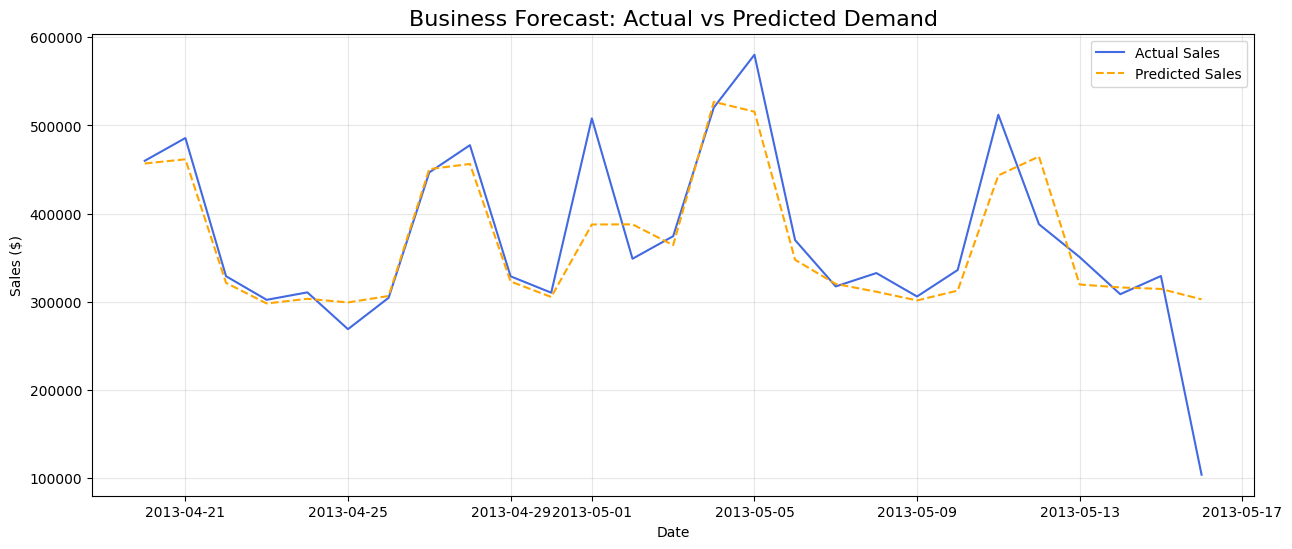

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
# Using the correct column name 'date' instead of 'Order Date'
plt.plot(daily_sales['date'].iloc[split:], y_test, label='Actual Sales', color='royalblue')
plt.plot(daily_sales['date'].iloc[split:], predictions, label='Predicted Sales', color='orange', linestyle='--')
plt.title('Business Forecast: Actual vs Predicted Demand', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()